# Preprocessing
**Dataset:** Credit Card Fraud Detection  


## Imports

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import json

In [2]:
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

os.makedirs('../results', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

## 1. Učitavanje sirovih podataka

In [3]:
DATA_PATH = '../data/creditcard.csv'

df = pd.read_csv(DATA_PATH)

## 2. Čišćenje podataka

In [5]:
dups = df[df.duplicated()]
print(dups['Class'].value_counts(normalize=True))

Class
0    0.982424
1    0.017576
Name: proportion, dtype: float64


Duplikate ne uklanjamo jer sadrže i legit i fraud transakcije, pa bi njihovo brisanje moglo narušiti realnu distribuciju podataka i uticati na kvalitet modela. Takođe, u PCA-transformisanom datasetu oni ne predstavljaju greške, već prirodna ponavljanja sličnih obrazaca transakcija.

## 3. Feature Engineering

U analizi smo transformisali Time i Amount varijable tako što smo Time prilagodili dnevnim obrascima (dan/noć), dok smo Amount log-transformacijom smanjili uticaj outliera i ublažili njegovu desnu asimetriju, čime je distribucija približena normalnijoj.

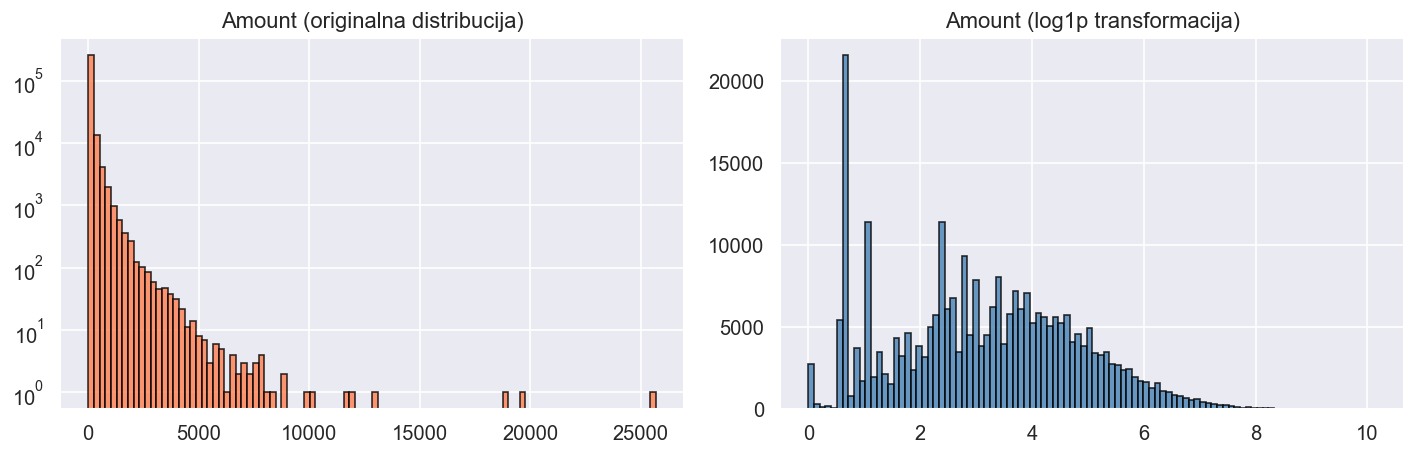

In [8]:
df_proc = df.copy()

seconds_in_day = 86400
df_proc['Time_sin'] = np.sin(2 * np.pi * df_proc['Time'] / seconds_in_day)
df_proc['Time_cos'] = np.cos(2 * np.pi * df_proc['Time'] / seconds_in_day)

df_proc['Amount_log'] = np.log1p(df_proc['Amount'])

df_proc = df_proc.drop(columns=['Time', 'Amount'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Amount'], bins=100, color='coral', alpha=0.8, edgecolor='black')
axes[0].set_title('Amount (originalna distribucija)')
axes[0].set_yscale('log')
axes[1].hist(df_proc['Amount_log'], bins=100, color='steelblue', alpha=0.8, edgecolor='black')
axes[1].set_title('Amount (log1p transformacija)')
plt.tight_layout()
plt.show()

## 4. Train/Test Split

In [11]:
X = df_proc.drop(columns=['Class'])
y = df_proc['Class']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print(f'\nTrain: {X_train.shape} , Fraud: {y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'Val:   {X_val.shape}   , Fraud: {y_val.sum()} ({y_val.mean()*100:.2f}%)')
print(f'Test:  {X_test.shape}  , Fraud: {y_test.sum()} ({y_test.mean()*100:.2f}%)')


Train: (199364, 31) , Fraud: 344 (0.17%)
Val:   (42721, 31)   , Fraud: 74 (0.17%)
Test:  (42722, 31)  , Fraud: 74 (0.17%)


## 5. Skaliranje featuera

X_train_scaled — mean: 0.0157, std: 1.2664


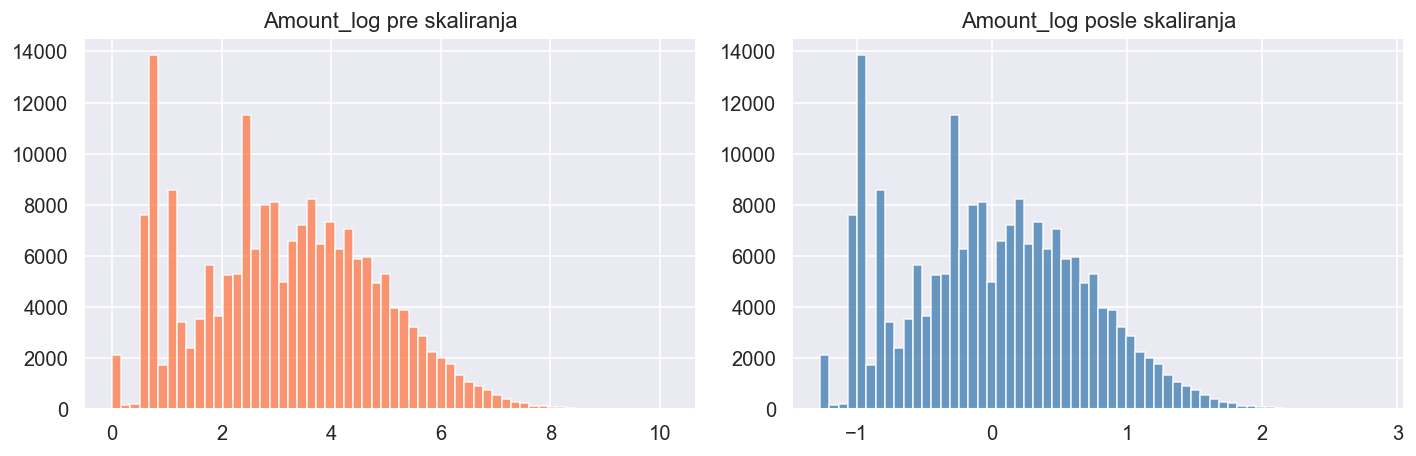

['../models/robust_scaler.pkl']

In [15]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f'X_train_scaled — mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}')

amount_idx = list(X.columns).index('Amount_log')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train['Amount_log'], bins=60, color='coral', alpha=0.8)
axes[0].set_title('Amount_log pre skaliranja')
axes[1].hist(X_train_scaled[:, amount_idx], bins=60, color='steelblue', alpha=0.8)
axes[1].set_title('Amount_log posle skaliranja')
plt.tight_layout()
plt.show()

joblib.dump(scaler, '../models/robust_scaler.pkl')

## 6. Tretman nebalansiranosti klasa



In [20]:
print(f'Distribucija: {Counter(y_train)}')

smote = SMOTE(sampling_strategy=0.1, random_state=RANDOM_SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f'Distribucija: {Counter(y_train_smote)}')
print(f'Shape: {X_train_smote.shape}')

over  = SMOTE(sampling_strategy=0.1, random_state=RANDOM_SEED, k_neighbors=5)
under = RandomUnderSampler(sampling_strategy=0.5, random_state=RANDOM_SEED)
pipeline = ImbPipeline([('over', over), ('under', under)])
X_train_combined, y_train_combined = pipeline.fit_resample(X_train_scaled, y_train)
print(f'Distribucija: {Counter(y_train_combined)}')
print(f'Shape: {X_train_combined.shape}')

Distribucija: Counter({0: 199020, 1: 344})
Distribucija: Counter({0: 199020, 1: 19902})
Shape: (218922, 31)
Distribucija: Counter({0: 39804, 1: 19902})
Shape: (59706, 31)


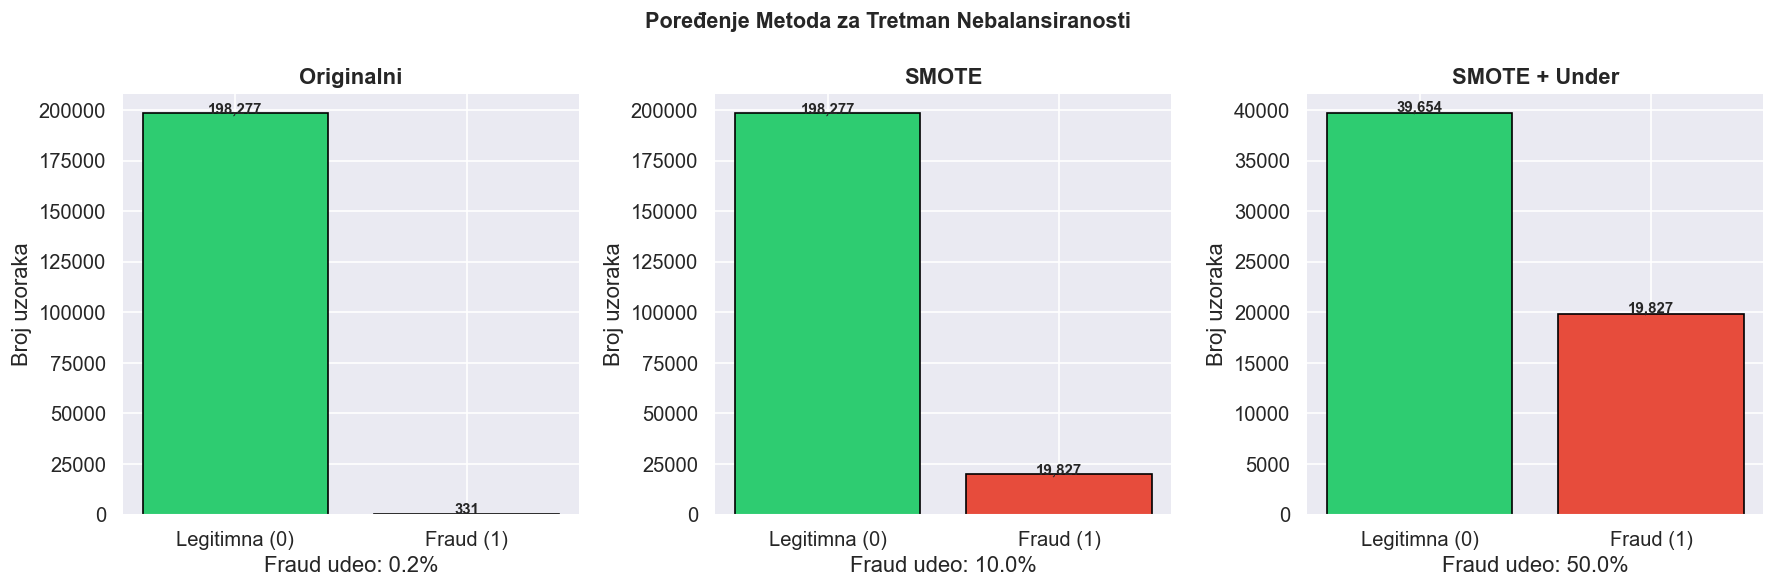

In [9]:
methods = {
    'Originalni': Counter(y_train),
    'SMOTE': Counter(y_train_smote),
    'SMOTE + Under': Counter(y_train_combined)
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = [['#2ecc71', '#e74c3c']] * 3

for ax, (name, counts) in zip(axes, methods.items()):
    labels = ['Legitimna (0)', 'Fraud (1)']
    vals = [counts[0], counts[1]]
    bars = ax.bar(labels, vals, color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Broj uzoraka')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,}', ha='center', fontsize=9, fontweight='bold')
    ratio = vals[1] / vals[0] * 100
    ax.set_xlabel(f'Fraud udeo: {ratio:.1f}%')

plt.suptitle('Poređenje Metoda za Tretman Nebalansiranosti', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/02_balancing_comparison.png', bbox_inches='tight')
plt.show()

## 7. Računanje class_weight za loss funkciju

In [21]:
classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print('Class weights (za Keras/PyTorch loss):')  
print(f'  Klasa 0 (legitimna): {class_weight_dict[0]:.4f}')
print(f'  Klasa 1 (fraud):     {class_weight_dict[1]:.4f}')
print(f'  Odnos:               1 : {class_weight_dict[1]/class_weight_dict[0]:.1f}')

Class weights (za Keras/PyTorch loss):
  Klasa 0 (legitimna): 0.5009
  Klasa 1 (fraud):     289.7733
  Odnos:               1 : 578.5


## 8. Čuvanje procesiranih podataka

In [26]:
PROC_PATH = '../data/processed/'

np.save(f'{PROC_PATH}X_train.npy', X_train_scaled)
np.save(f'{PROC_PATH}X_val.npy', X_val_scaled)
np.save(f'{PROC_PATH}X_test.npy', X_test_scaled)
np.save(f'{PROC_PATH}y_train.npy', y_train.values)
np.save(f'{PROC_PATH}y_val.npy', y_val.values)
np.save(f'{PROC_PATH}y_test.npy', y_test.values)
np.save(f'{PROC_PATH}X_train_smote.npy', X_train_smote)
np.save(f'{PROC_PATH}y_train_smote.npy', y_train_smote)
np.save(f'{PROC_PATH}X_train_combined.npy', X_train_combined)
np.save(f'{PROC_PATH}y_train_combined.npy', y_train_combined)

with open(f'{PROC_PATH}class_weights.json', 'w') as f:
    json.dump({str(k): v for k, v in class_weight_dict.items()}, f)

feature_names = list(X.columns)
with open(f'{PROC_PATH}feature_names.json', 'w') as f:
    json.dump(feature_names, f)